<!-- ABD_TA_BENCHMARKING_DASHBOARD -->
# Benchmarking Dashboard

This dashboard benchmarks the teams using actual BEAT values first, then normalized 0-100 category scores. Both CO2 benchmarking metrics are shown in the BEAT dashboard and individual BEAT figures. Category scoring uses only `CO2 (kgCO2/year/desk)` (BEATS D) for Sustainability; Team 8 CO2 (BEATS D) and Energy Resilience outliers are excluded from normalization and assigned 0 in category scoring. Non-numeric entries such as `-`, `---`, `x`, `xxx`, and `%` are treated as missing values.


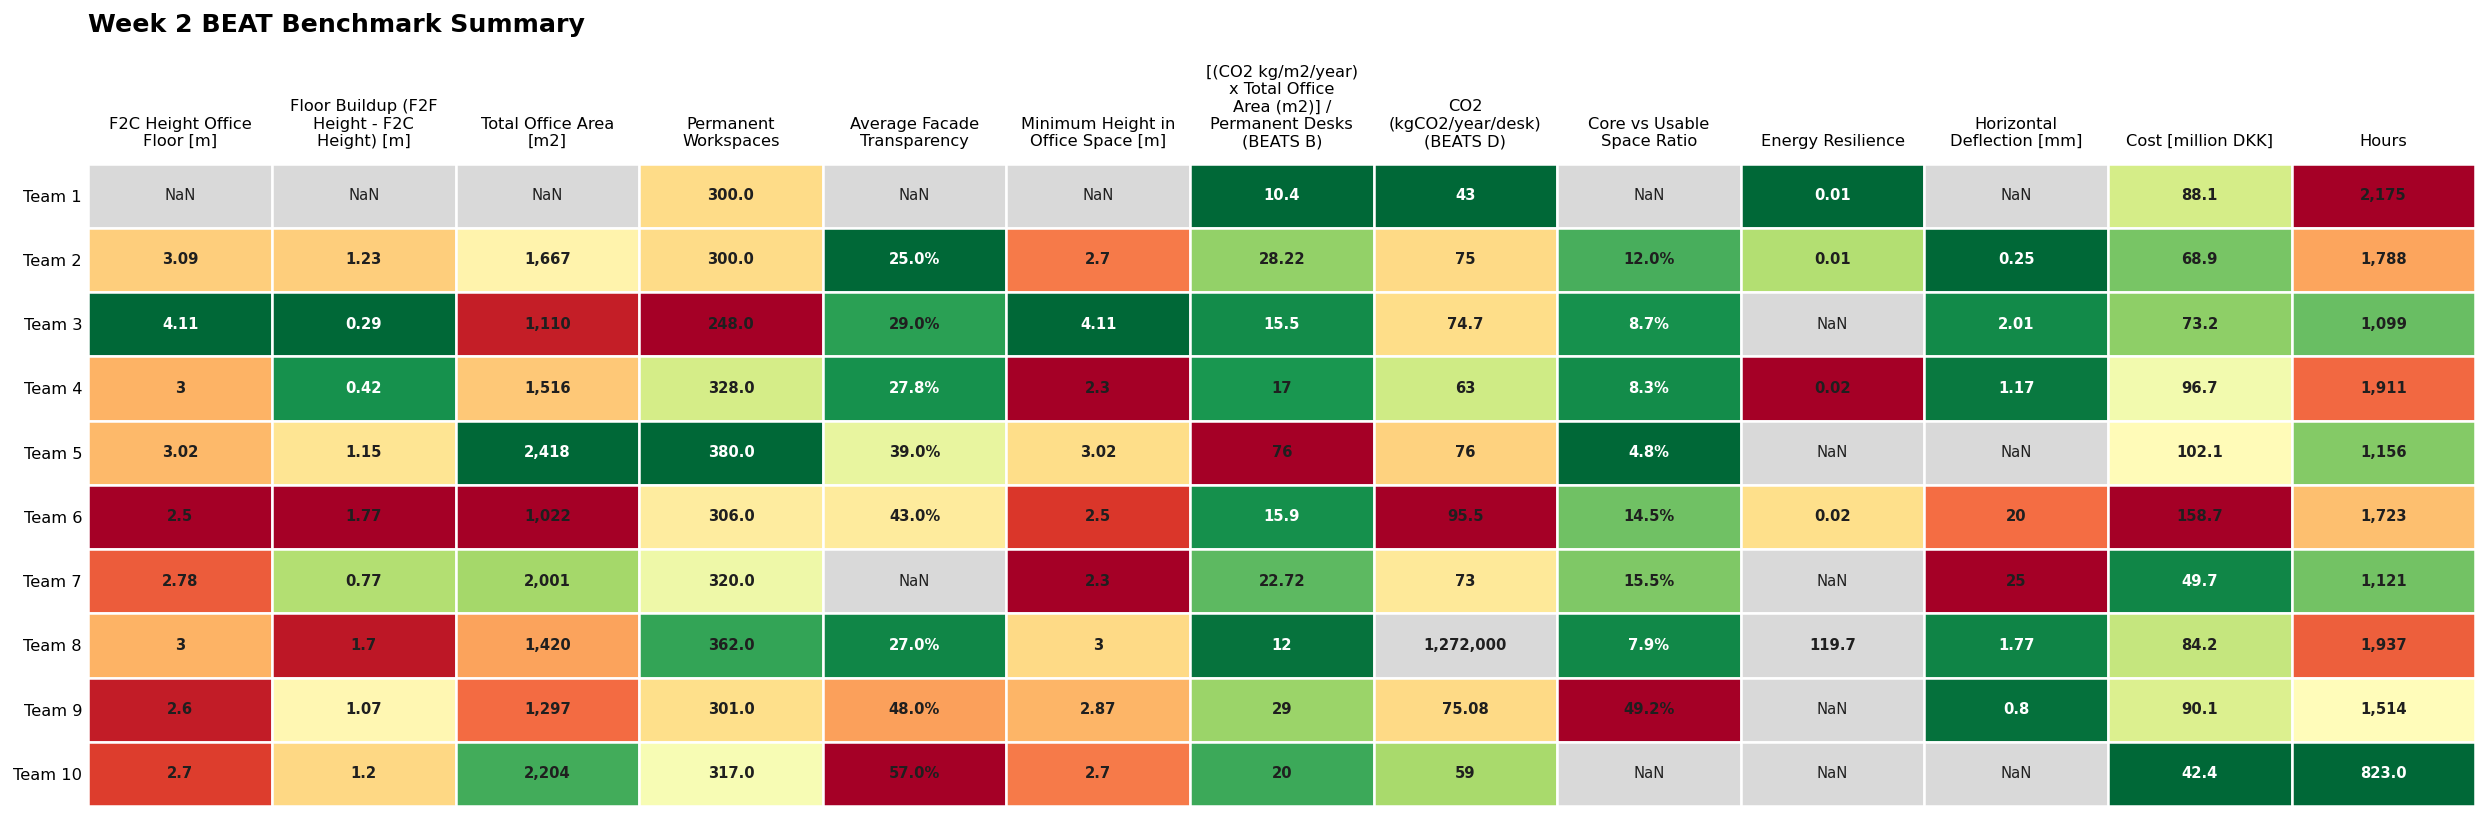

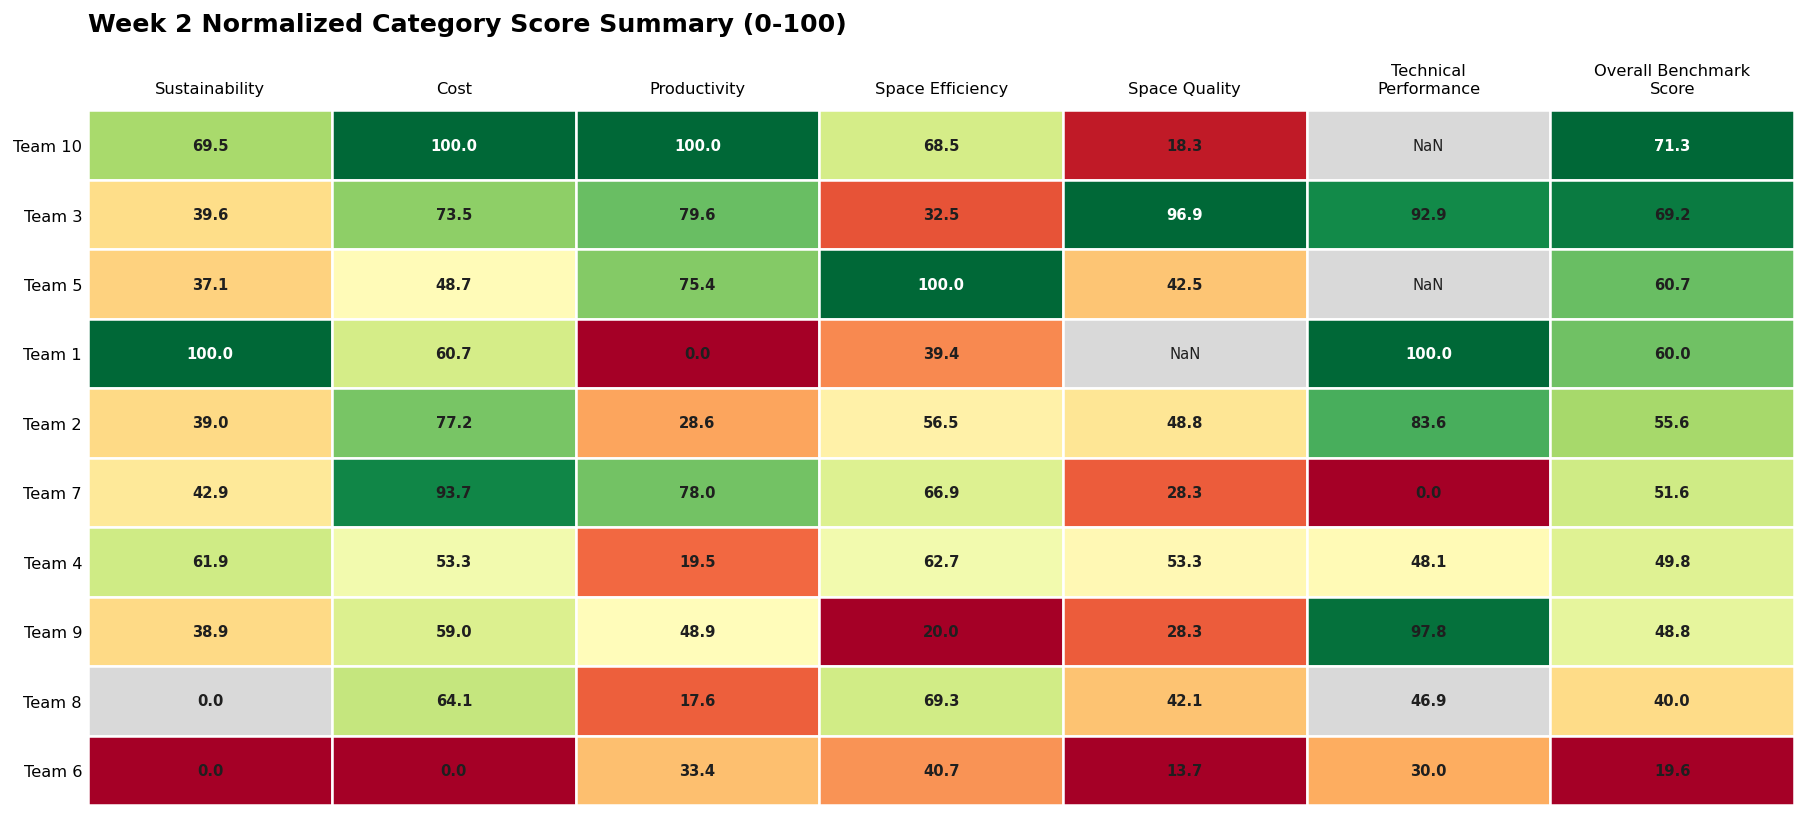

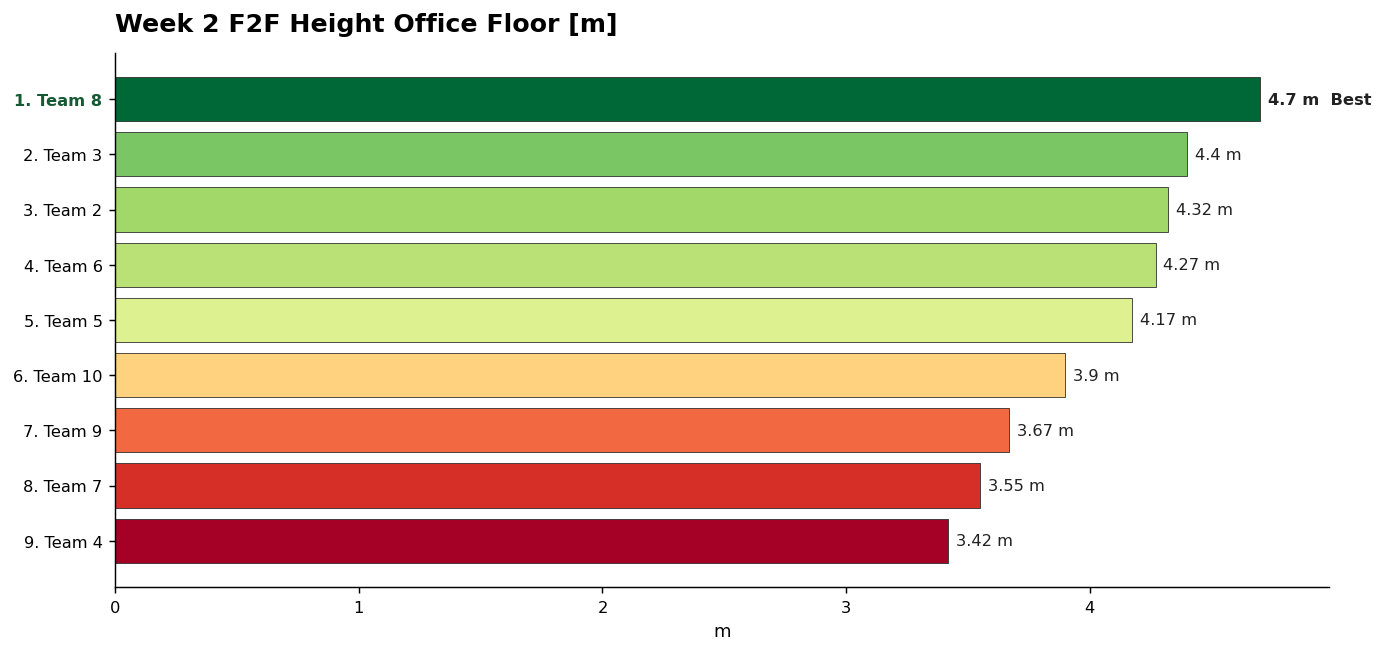

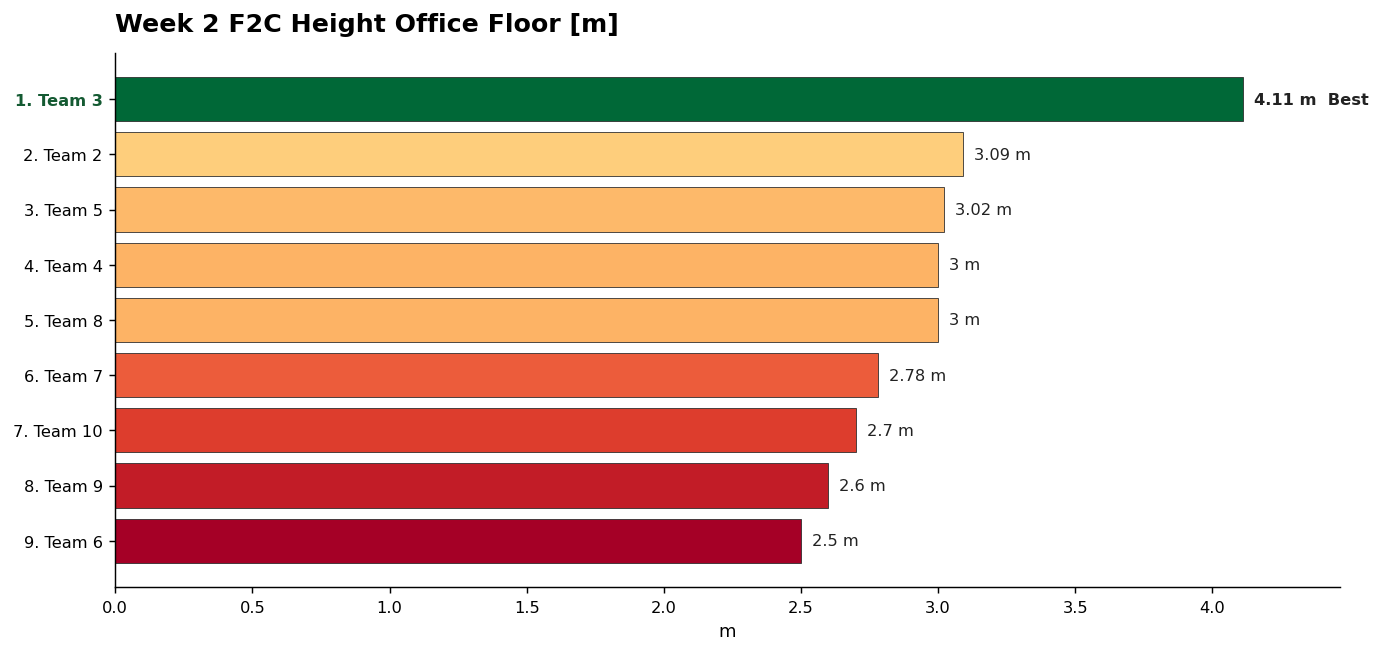

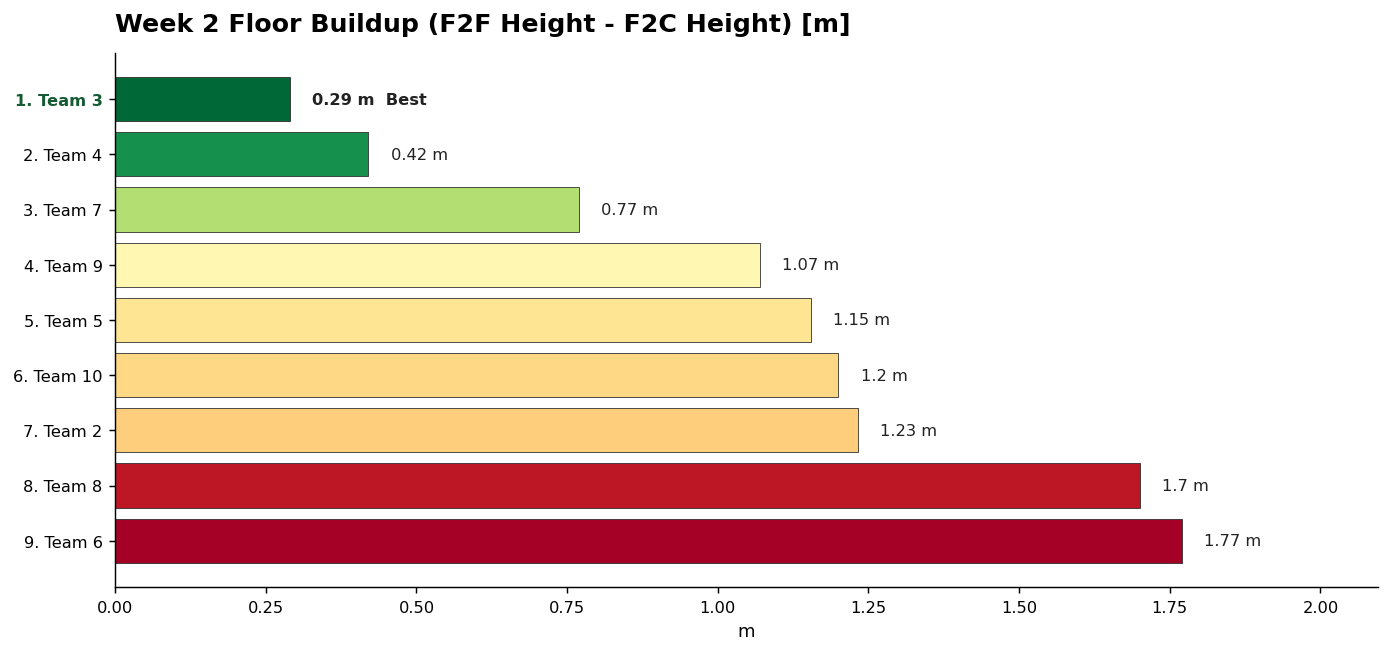

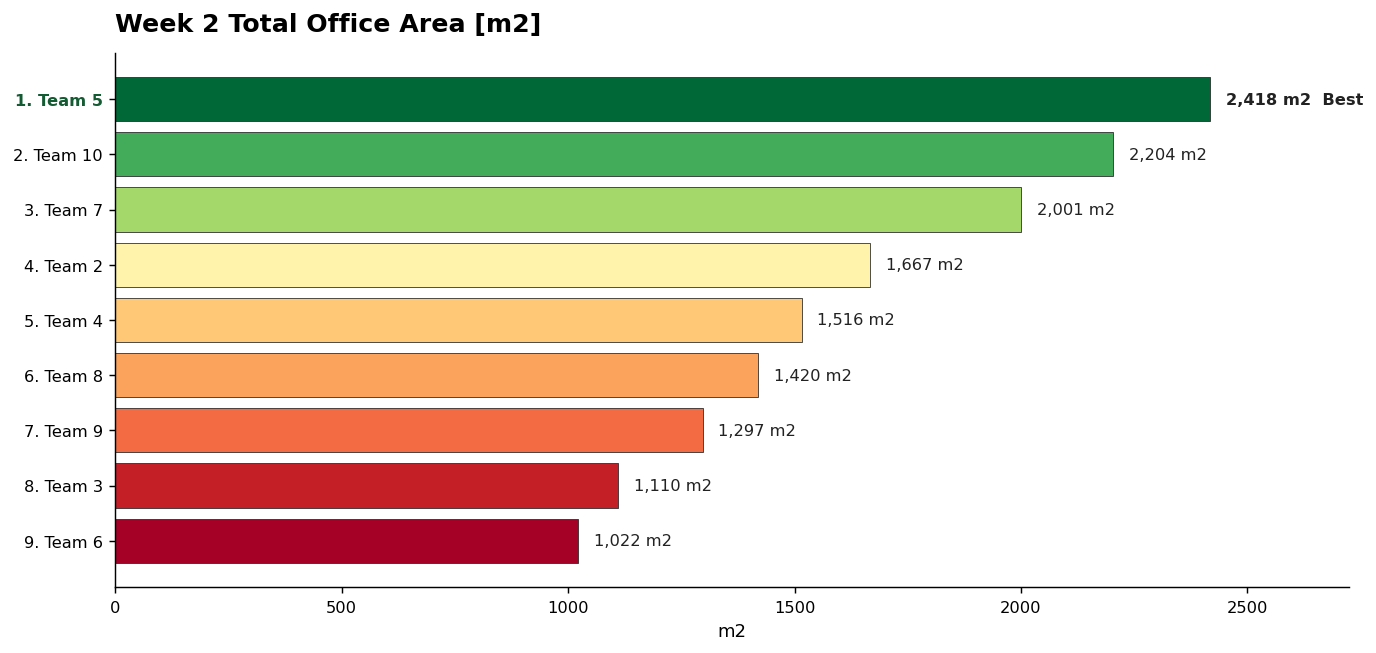

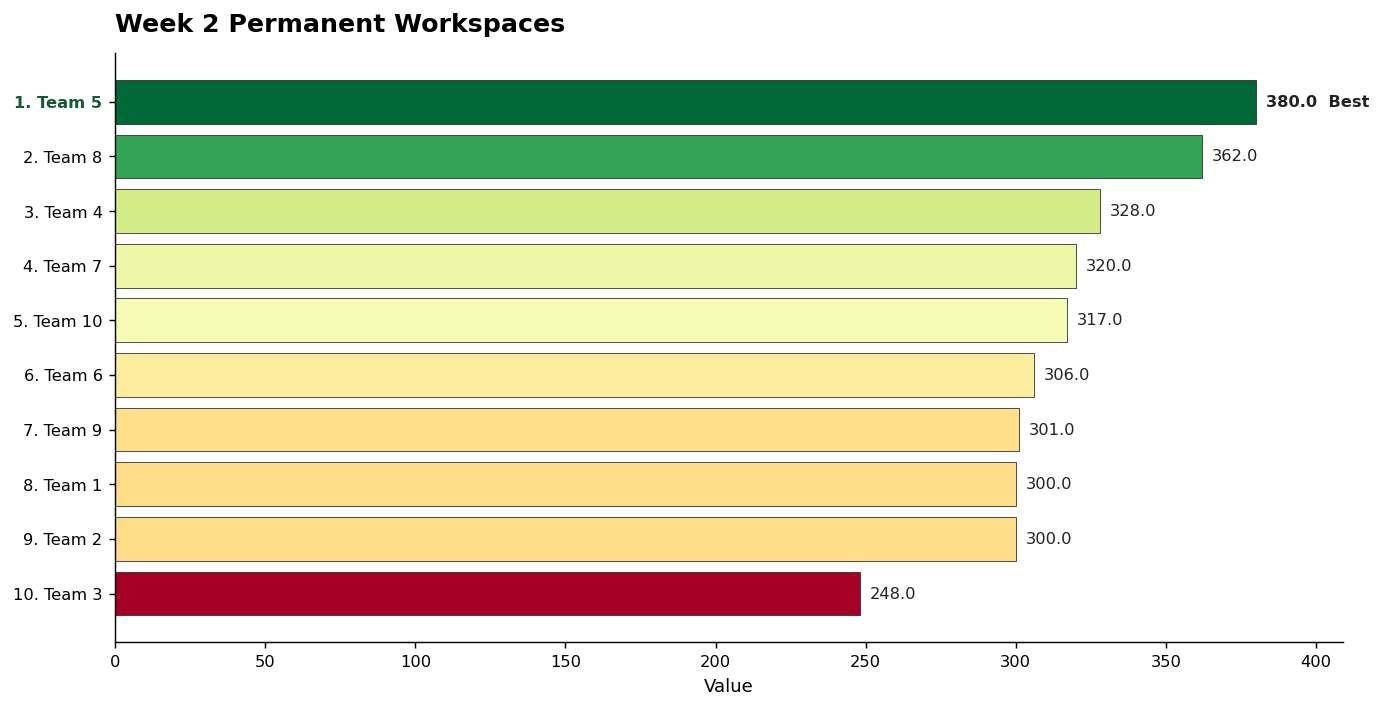

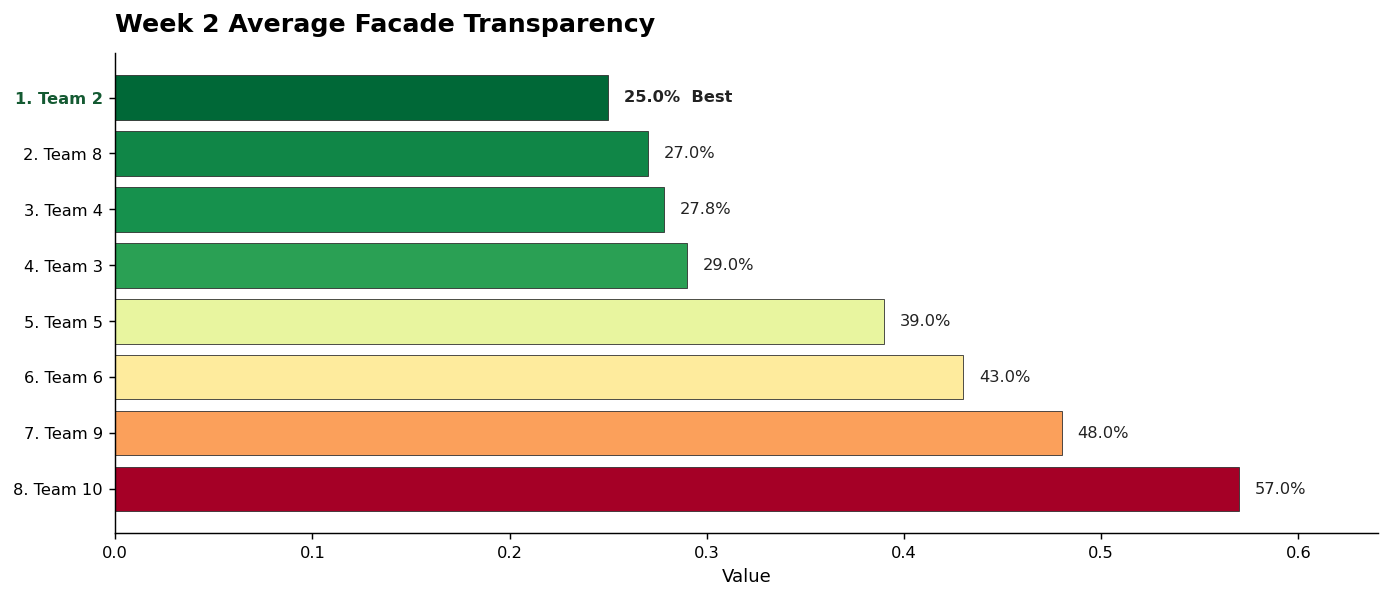

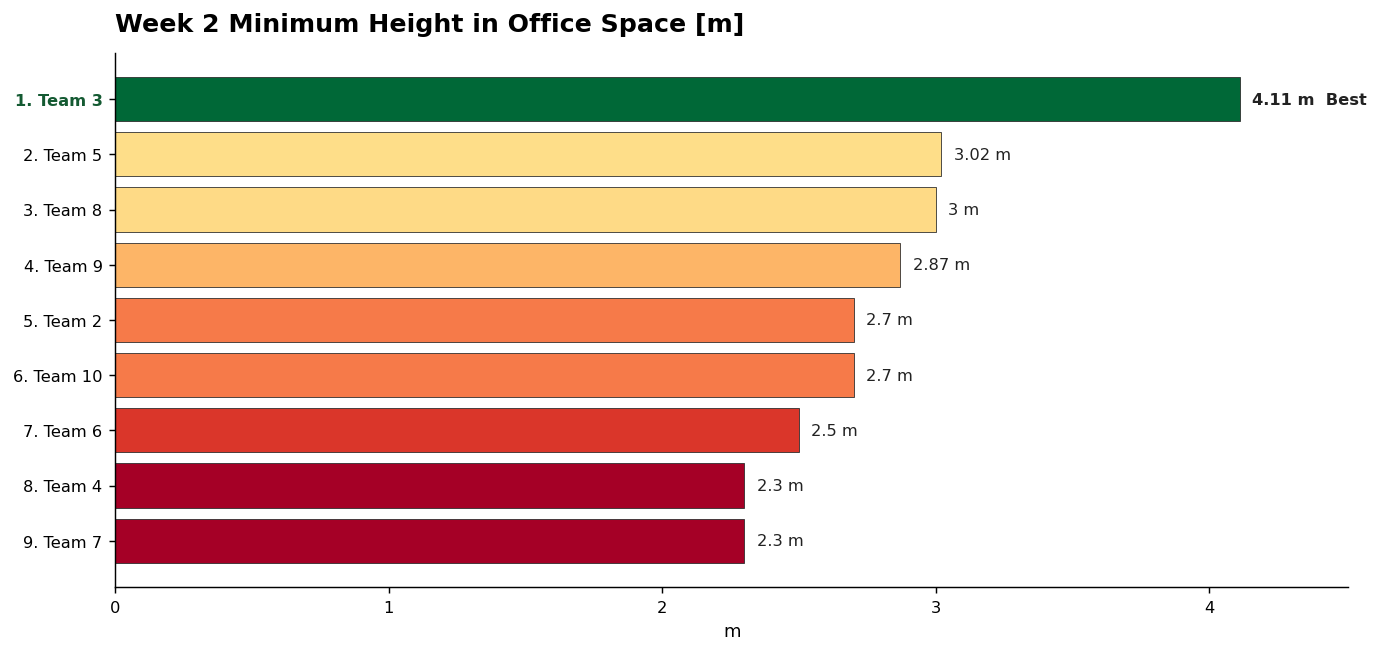

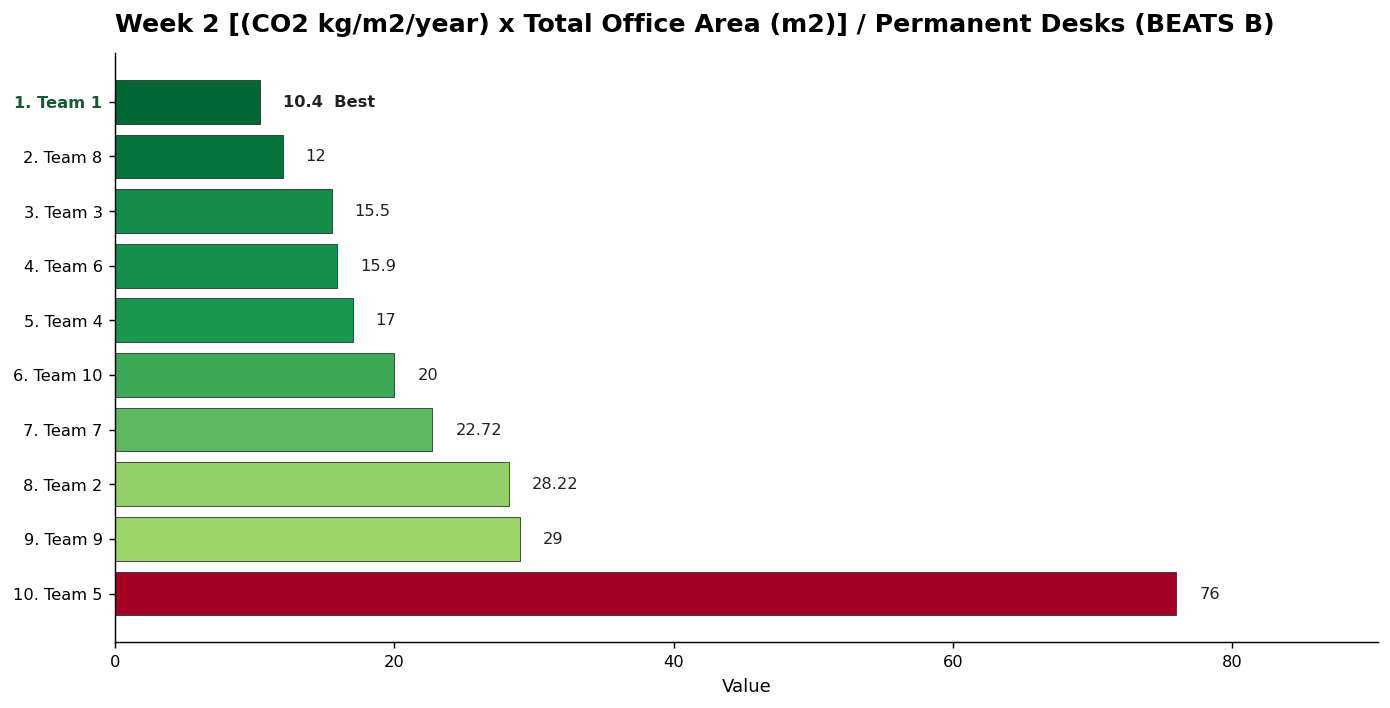

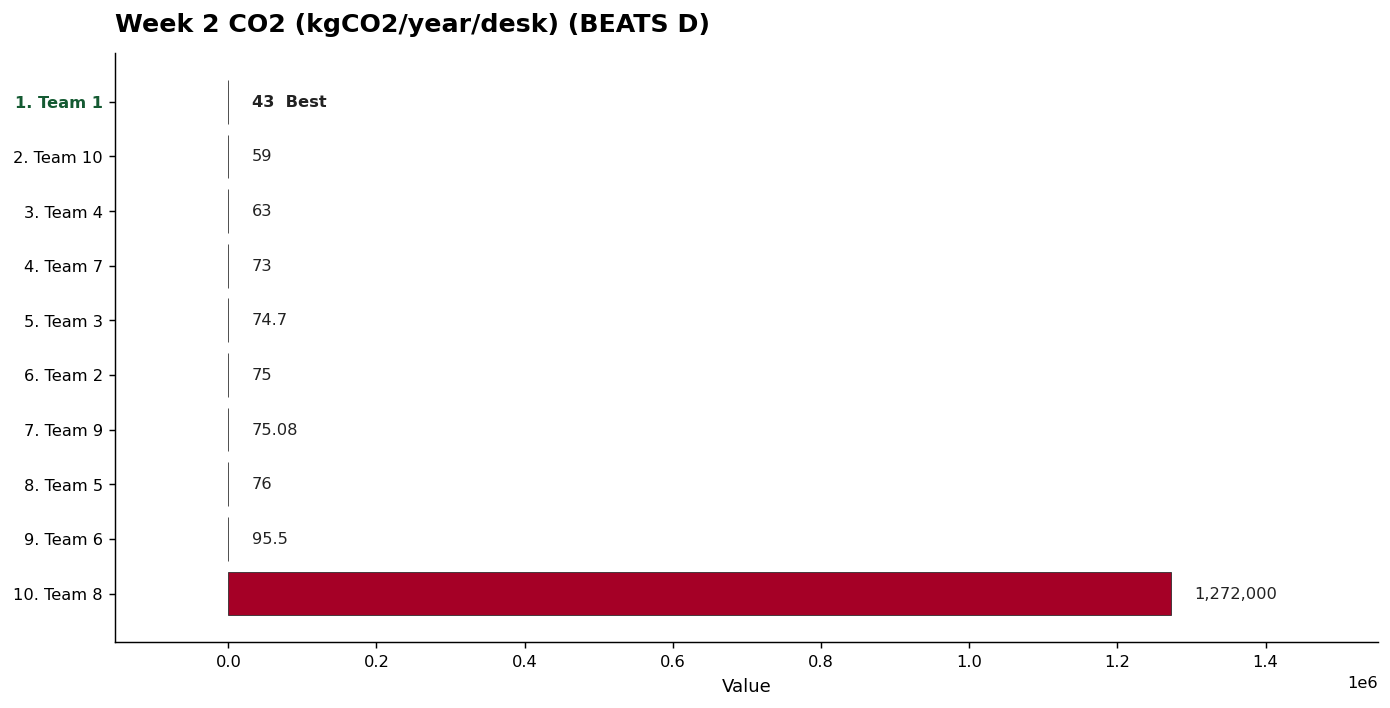

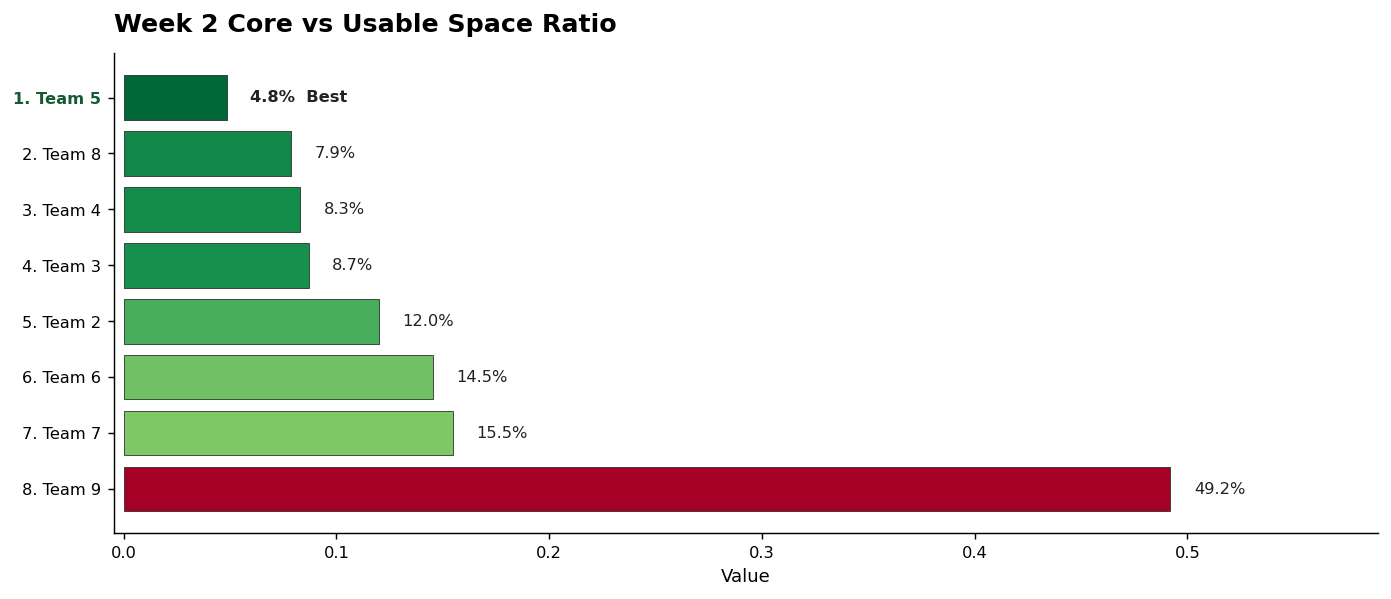

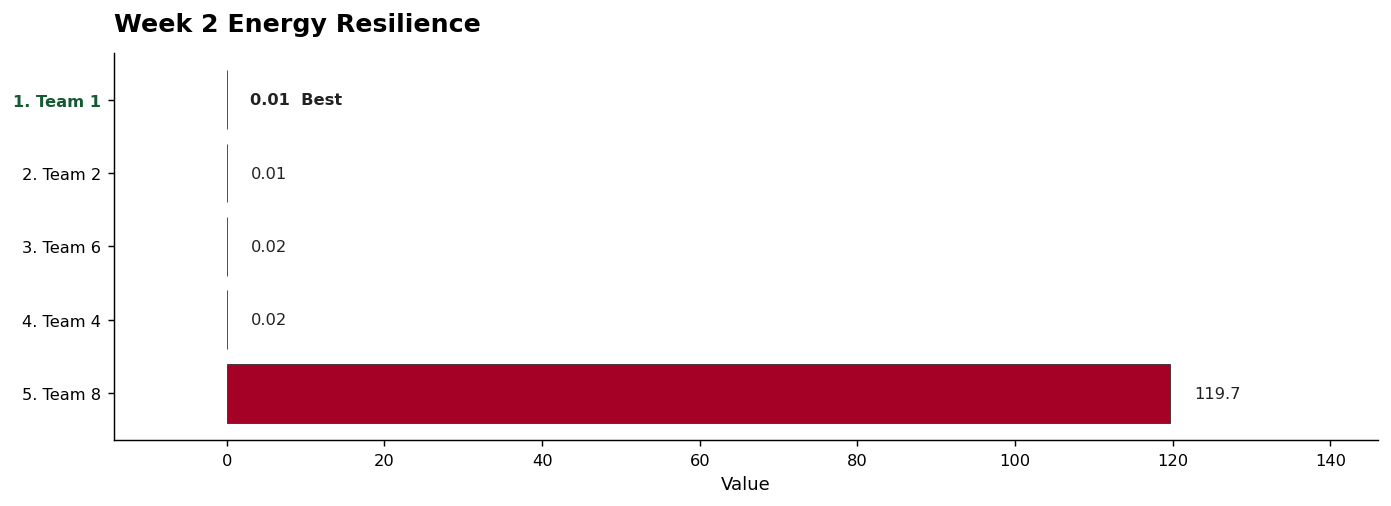

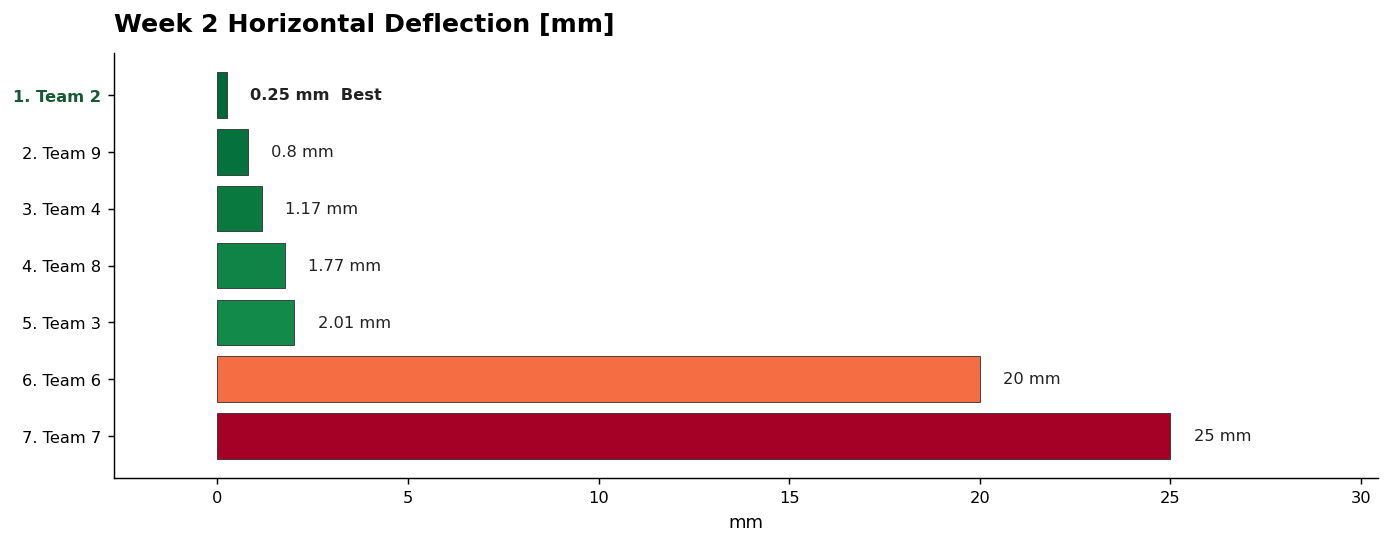

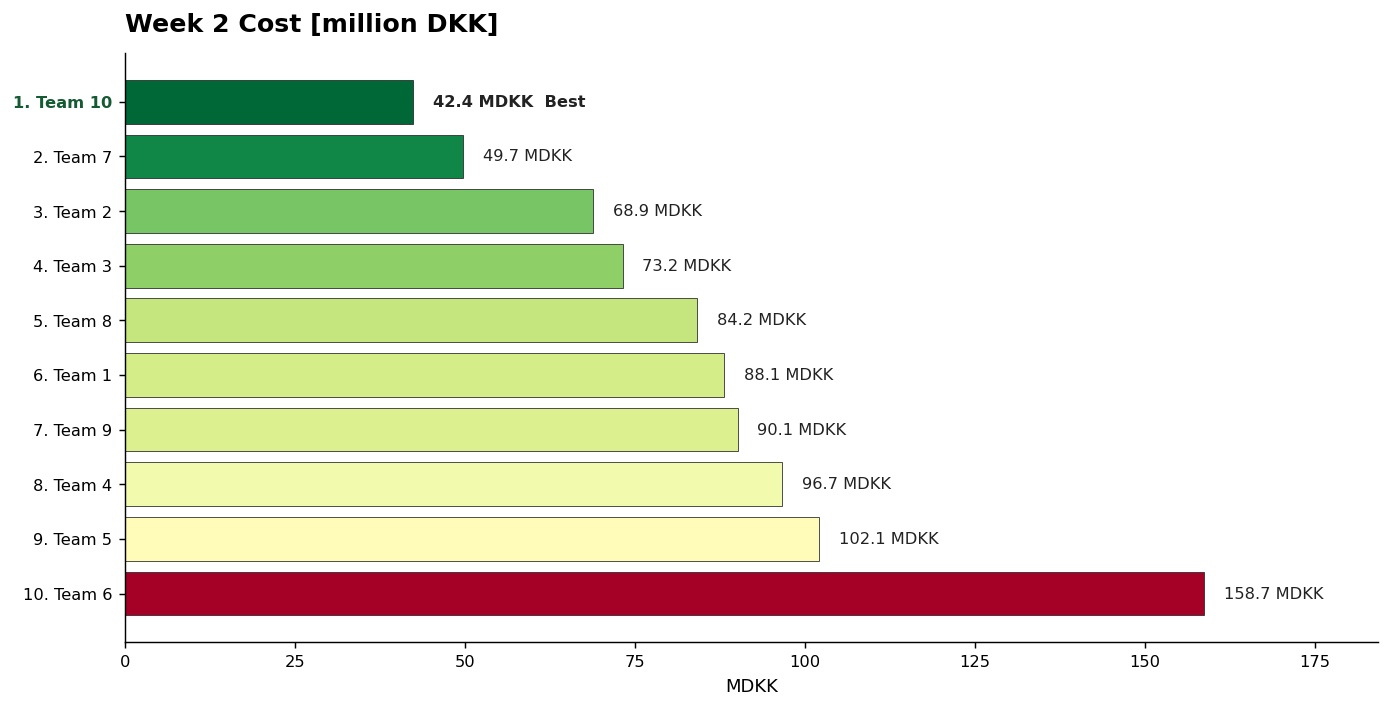

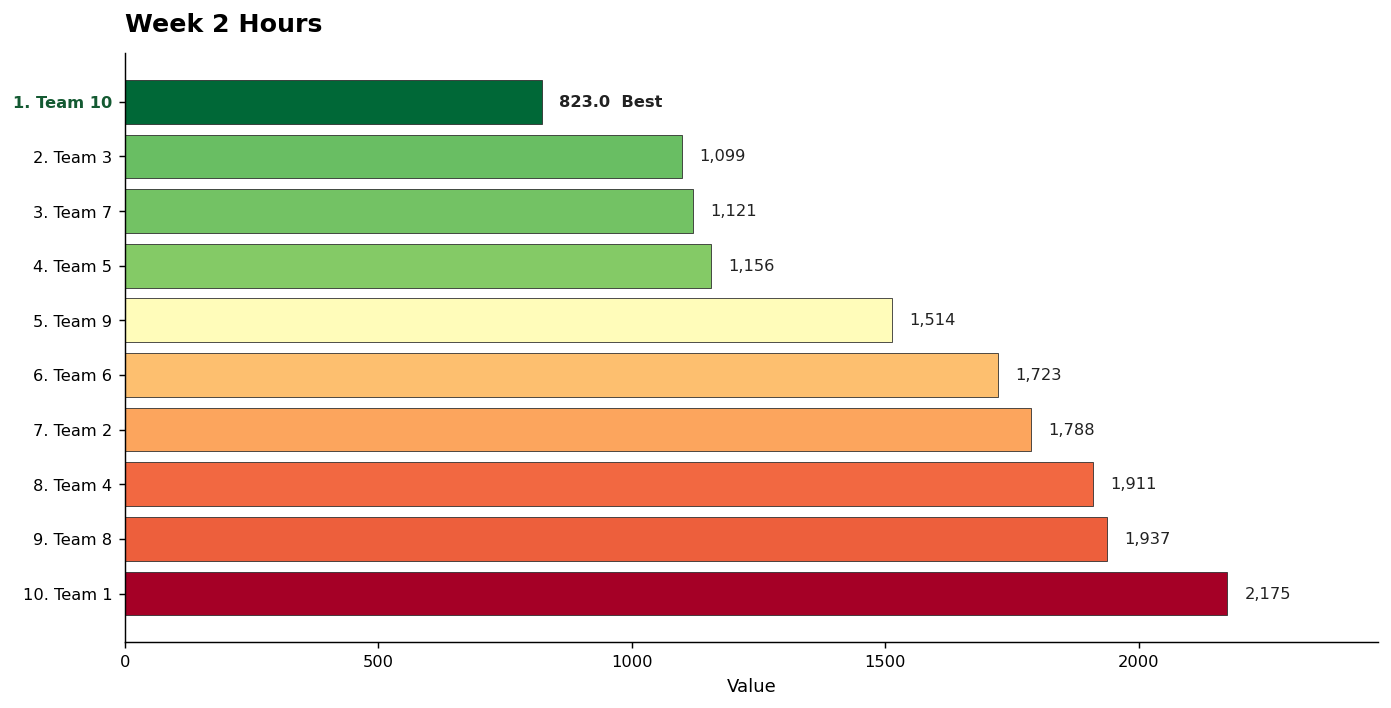

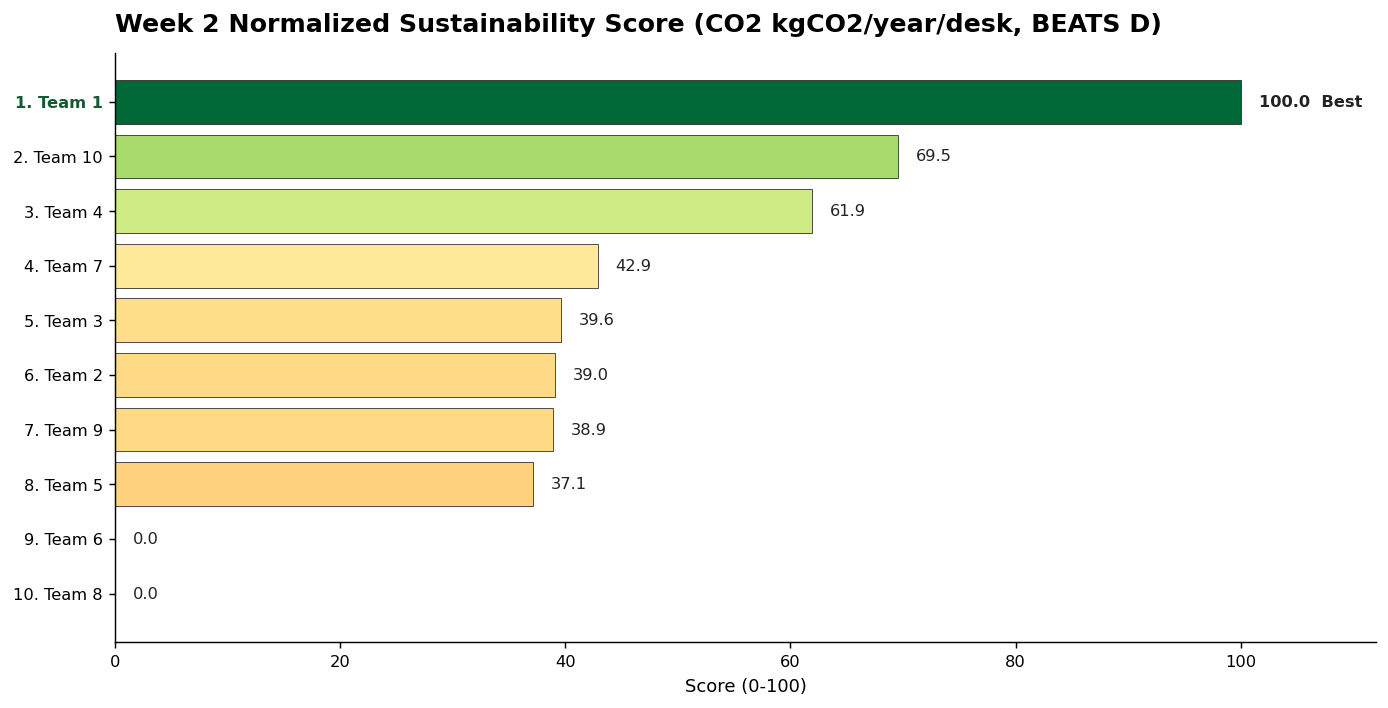

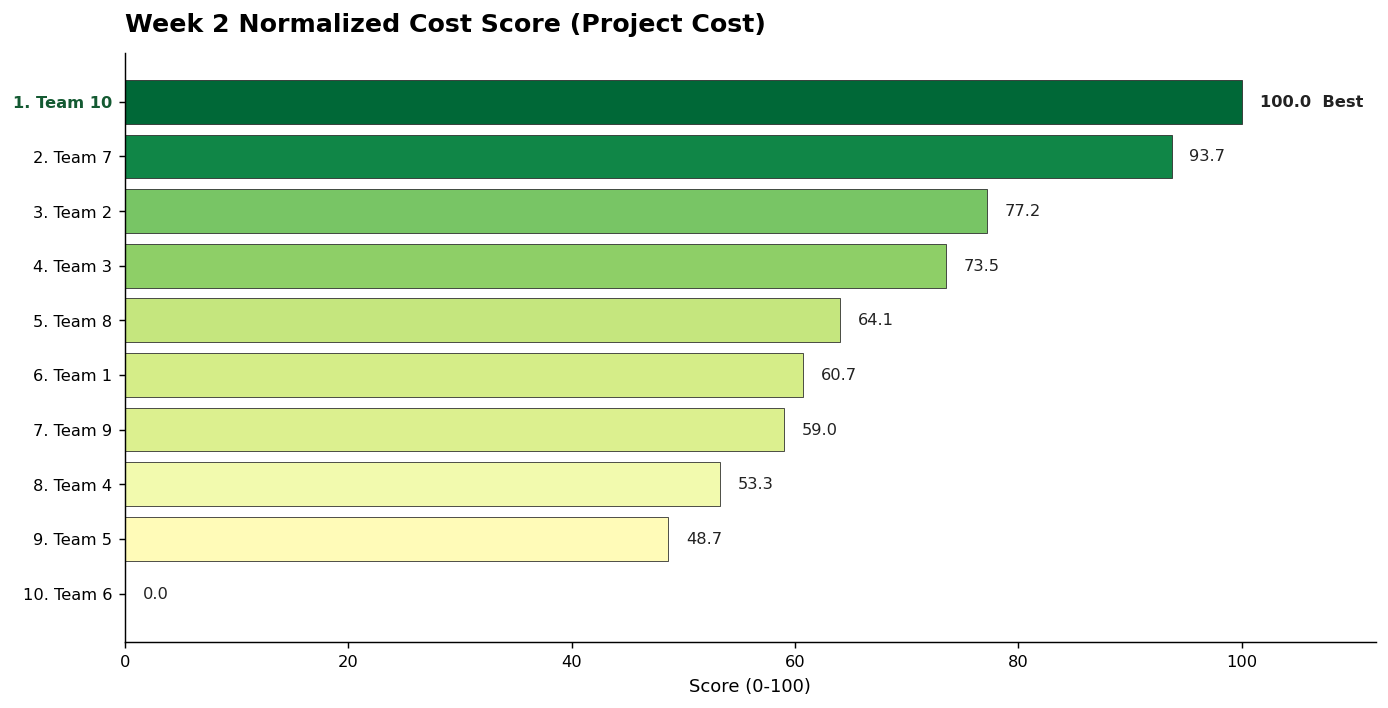

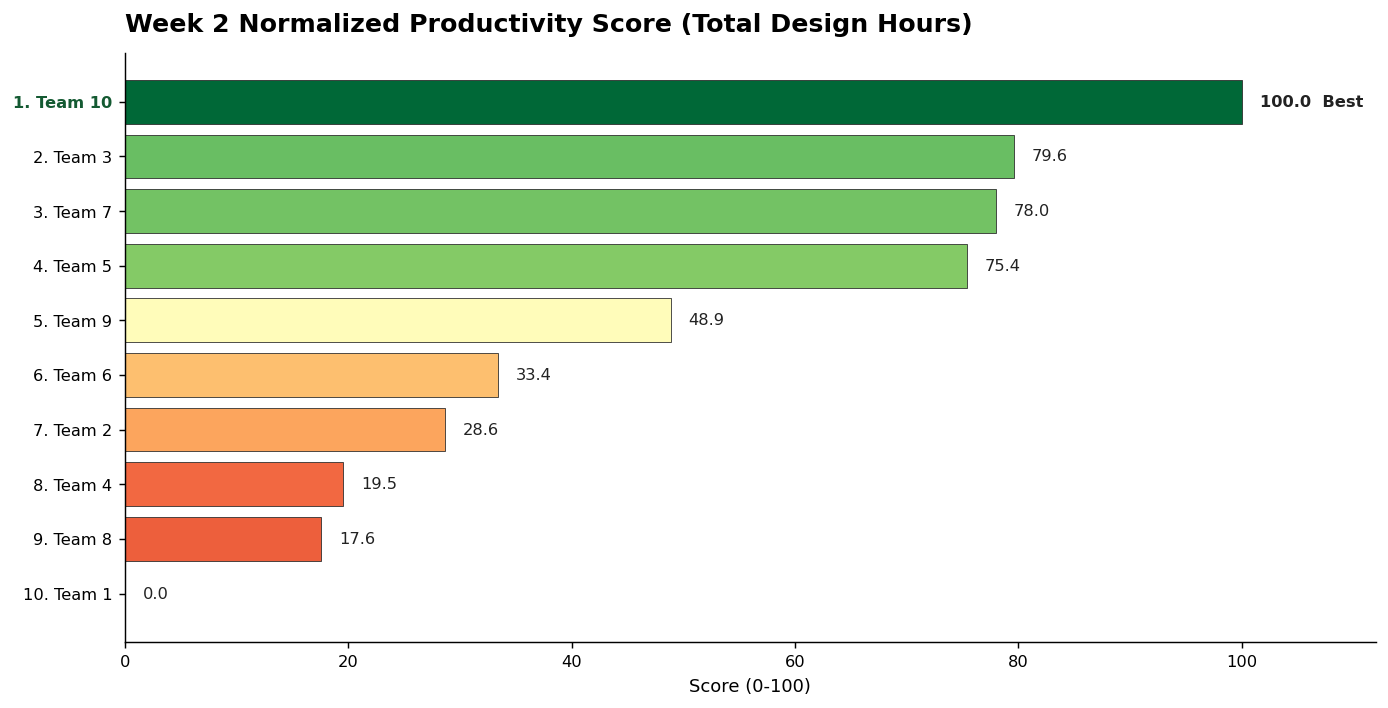

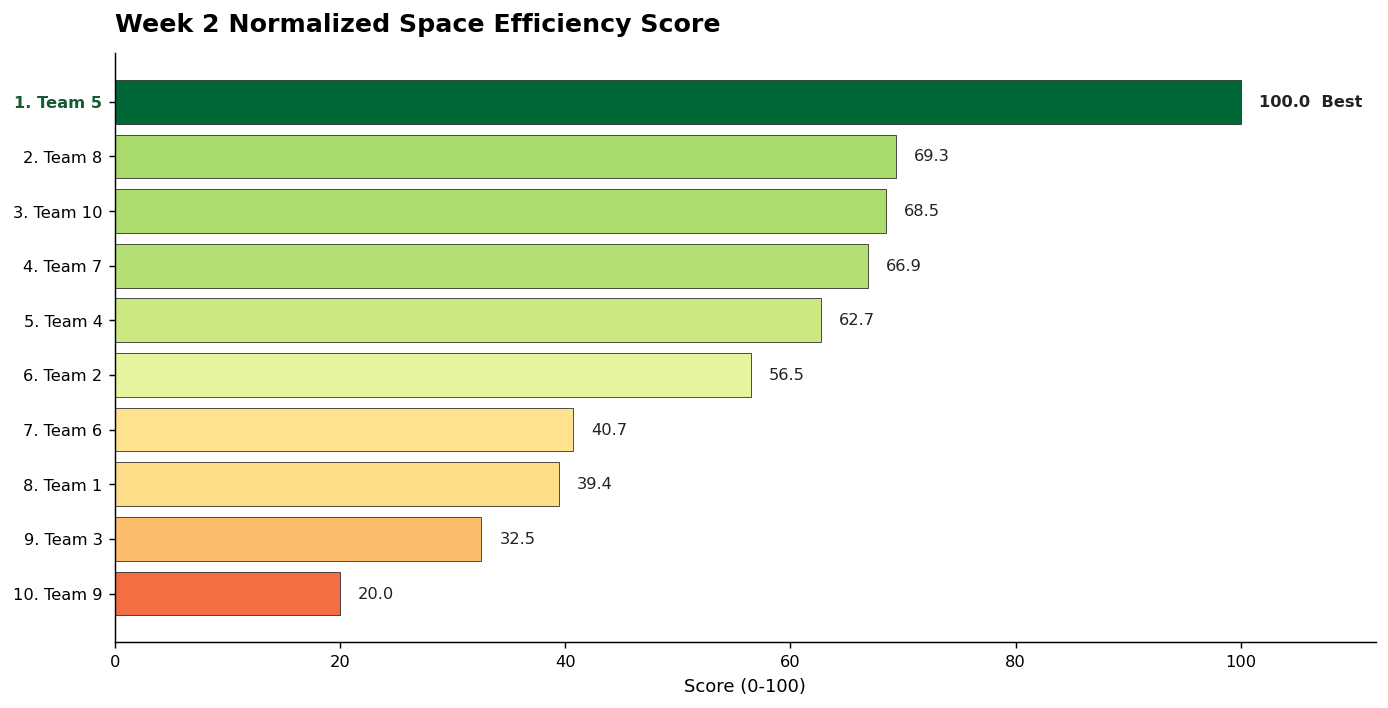

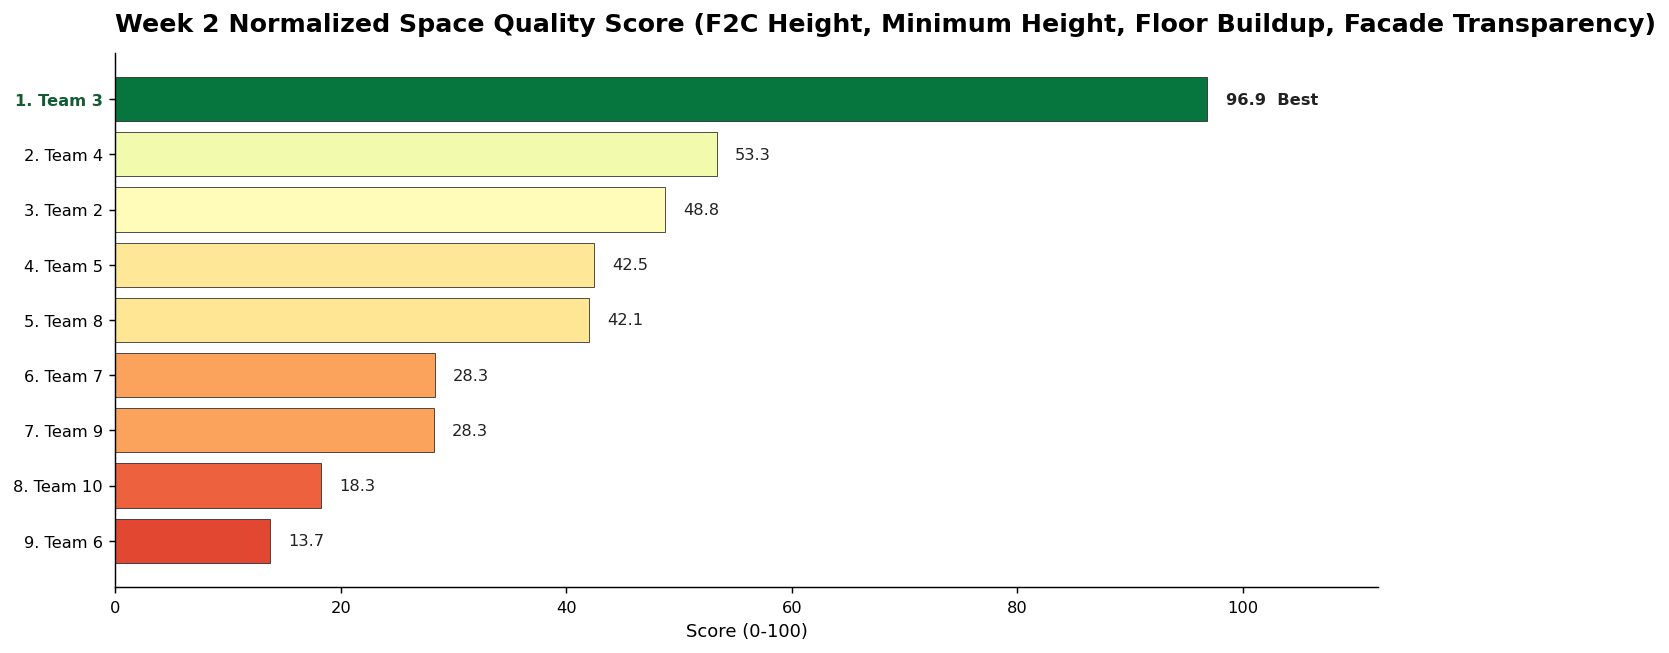

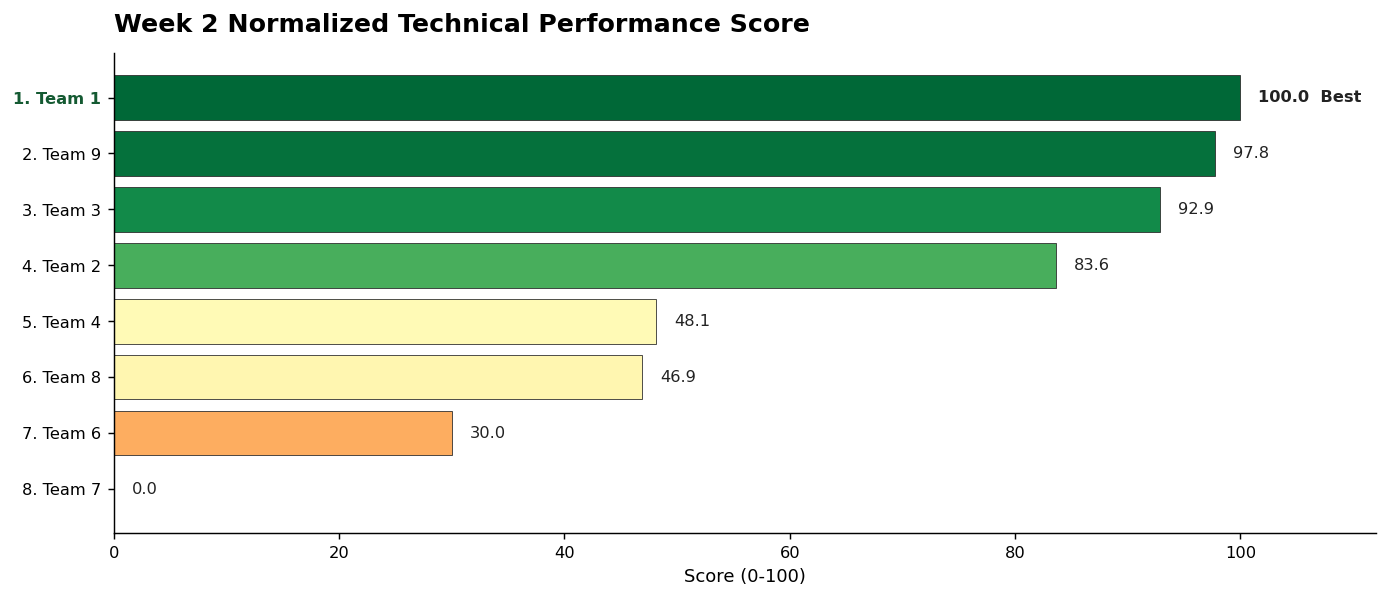

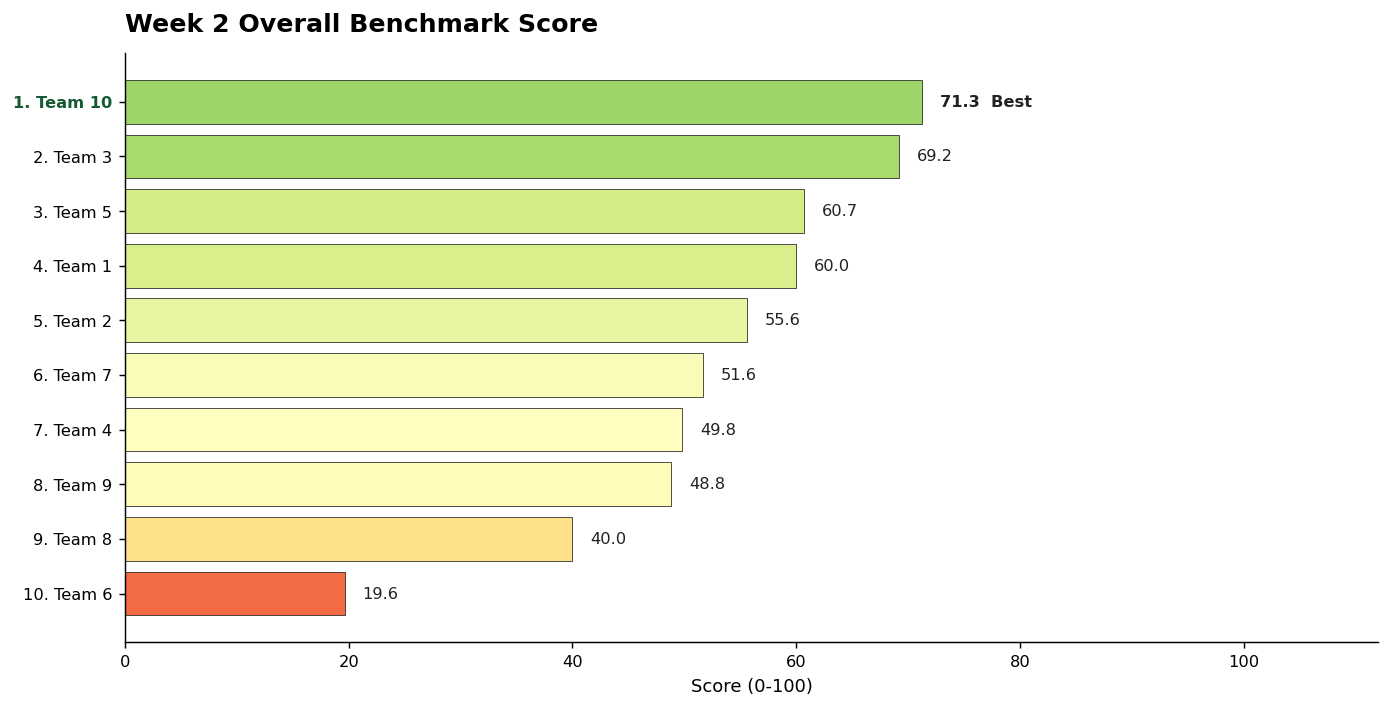

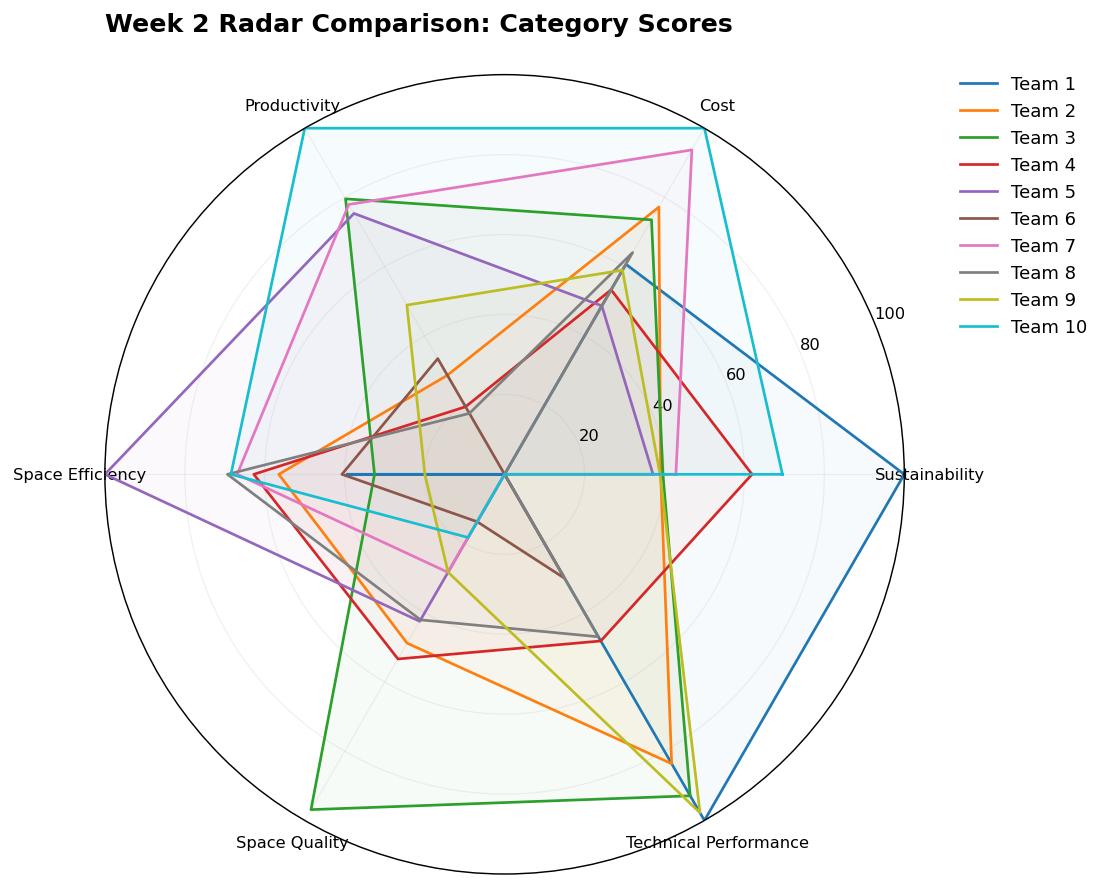

In [5]:
import re
import textwrap
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors



plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 14,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "grid.linewidth": 0.7,
})

raw_rows = [
    {"Team": "Team 1", "Floor area [m2]": "", "F2F Height [m]": "", "F2F Height Office Floor [m]": "", "F2C Height Office Floor [m]": "", "Total Office Area [m2]": "", "Total Desks": "300", "Permanent Workspaces": "300", "Average Facade Transparency": "", "Minimum Height in Office Space [m]": "", "CO2 BEATS B": "10,4", "Core vs Usable Space Ratio": "", "Energy Resilience": "0,006 kW/m2 - 0,03 kW/m2", "Horizontal Deflection": "", "CO2 (kgCO2/year/desk)": "43", "Cost": "88.1 MDKK", "Hours": "2175"},
    {"Team": "Team 2", "Floor area [m2]": "7710", "F2F Height [m]": "3,68", "F2F Height Office Floor [m]": "4,322", "F2C Height Office Floor [m]": "3,09", "Total Office Area [m2]": "1667", "Total Desks": "300", "Permanent Workspaces": "300", "Average Facade Transparency": "25%", "Minimum Height in Office Space [m]": "2,7", "CO2 BEATS B": "28,22", "Core vs Usable Space Ratio": "12%", "Energy Resilience": "0,012kW/m2 / 0,25 mm", "Horizontal Deflection": "0,25 mm", "CO2 (kgCO2/year/desk)": "75", "Cost": "68,9 MDKK", "Hours": "1788"},
    {"Team": "Team 3", "Floor area [m2]": "4920", "F2F Height [m]": "3,59", "F2F Height Office Floor [m]": "4,4", "F2C Height Office Floor [m]": "4,11", "Total Office Area [m2]": "1110", "Total Desks": "248", "Permanent Workspaces": "248", "Average Facade Transparency": "29%", "Minimum Height in Office Space [m]": "4,11", "CO2 BEATS B": "15,5", "Core vs Usable Space Ratio": "8,70%", "Energy Resilience": "-", "Horizontal Deflection": "2.012mm", "CO2 (kgCO2/year/desk)": "74,7", "Cost": "73,2 mio. DKK", "Hours": "1099"},
    {"Team": "Team 4", "Floor area [m2]": "5.804", "F2F Height [m]": "3,73", "F2F Height Office Floor [m]": "3,42", "F2C Height Office Floor [m]": "3", "Total Office Area [m2]": "1515,82", "Total Desks": "383", "Permanent Workspaces": "328", "Average Facade Transparency": "27,84%", "Minimum Height in Office Space [m]": "2,3", "CO2 BEATS B": "17", "Core vs Usable Space Ratio": "8,29%", "Energy Resilience": "H: 0,0243 kW/m2", "Horizontal Deflection": "1.168 mm", "CO2 (kgCO2/year/desk)": "63", "Cost": "96,7 million DKK", "Hours": "1911"},
    {"Team": "Team 5", "Floor area [m2]": "7294", "F2F Height [m]": "3,73", "F2F Height Office Floor [m]": "4,175", "F2C Height Office Floor [m]": "3,02", "Total Office Area [m2]": "2418", "Total Desks": "380", "Permanent Workspaces": "380", "Average Facade Transparency": "39%", "Minimum Height in Office Space [m]": "3,02", "CO2 BEATS B": "76", "Core vs Usable Space Ratio": "4,85%", "Energy Resilience": "", "Horizontal Deflection": "", "CO2 (kgCO2/year/desk)": "76", "Cost": "102,1 MDKK", "Hours": "1156"},
    {"Team": "Team 6", "Floor area [m2]": "6134", "F2F Height [m]": "3,67", "F2F Height Office Floor [m]": "4,27", "F2C Height Office Floor [m]": "2,5", "Total Office Area [m2]": "1022", "Total Desks": "306", "Permanent Workspaces": "306", "Average Facade Transparency": "43%", "Minimum Height in Office Space [m]": "2,5", "CO2 BEATS B": "15,9", "Core vs Usable Space Ratio": "14,54%", "Energy Resilience": "0,017 / 0,008", "Horizontal Deflection": "20mm", "CO2 (kgCO2/year/desk)": "95,5", "Cost": "158,7 mio DKK", "Hours": "1723"},
    {"Team": "Team 7", "Floor area [m2]": "4081", "F2F Height [m]": "3,84", "F2F Height Office Floor [m]": "3,55", "F2C Height Office Floor [m]": "2,78", "Total Office Area [m2]": "2001", "Total Desks": "320", "Permanent Workspaces": "320", "Average Facade Transparency": "", "Minimum Height in Office Space [m]": "2,3", "CO2 BEATS B": "22,72", "Core vs Usable Space Ratio": "15,47%", "Energy Resilience": "", "Horizontal Deflection": "25 mm", "CO2 (kgCO2/year/desk)": "73", "Cost": "49,7 million", "Hours": "1121"},
    {"Team": "Team 8", "Floor area [m2]": "8731,64", "F2F Height [m]": "3,67", "F2F Height Office Floor [m]": "4,7", "F2C Height Office Floor [m]": "3", "Total Office Area [m2]": "1419,65", "Total Desks": "615", "Permanent Workspaces": "362", "Average Facade Transparency": "27%", "Minimum Height in Office Space [m]": "3", "CO2 BEATS B": "12", "Core vs Usable Space Ratio": "7,87%", "Energy Resilience": "119,7", "Horizontal Deflection": "1,77mm", "CO2 (kgCO2/year/desk)": "1272000", "Cost": "84,2 million", "Hours": "1937"},
    {"Team": "Team 9", "Floor area [m2]": "6011", "F2F Height [m]": "3,67", "F2F Height Office Floor [m]": "3,67", "F2C Height Office Floor [m]": "minimum 2,6", "Total Office Area [m2]": "1297", "Total Desks": "301", "Permanent Workspaces": "301", "Average Facade Transparency": "48%", "Minimum Height in Office Space [m]": "2,87", "CO2 BEATS B": "29", "Core vs Usable Space Ratio": "49,20%", "Energy Resilience": "", "Horizontal Deflection": "0,8 mm", "CO2 (kgCO2/year/desk)": "75,08", "Cost": "90.1 million", "Hours": "1514"},
    {"Team": "Team 10", "Floor area [m2]": "6346", "F2F Height [m]": "3,6", "F2F Height Office Floor [m]": "3,9", "F2C Height Office Floor [m]": "2,7", "Total Office Area [m2]": "2204", "Total Desks": "371", "Permanent Workspaces": "317", "Average Facade Transparency": "57%", "Minimum Height in Office Space [m]": "2,7", "CO2 BEATS B": "20", "Core vs Usable Space Ratio": "---", "Energy Resilience": "---", "Horizontal Deflection": "---", "CO2 (kgCO2/year/desk)": "59", "Cost": "42,4 million DKK", "Hours": "823"},
]

raw_df = pd.DataFrame(raw_rows)
na_tokens = {"", "-", "--", "---", "x", "xx", "xxx", "%", "#value!", "nan", "none"}

def normalized_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip().replace("\u00a0", " ")

def extract_numbers(value):
    text = normalized_text(value).lower()
    if text in na_tokens:
        return []
    text = text.replace(",", ".")
    matches = re.findall(r"(?<![A-Za-z])[-+]?\d+(?:\.\d+)?", text)
    return [float(match) for match in matches]

def to_number(value):
    numbers = extract_numbers(value)
    return numbers[0] if numbers else np.nan

def to_percent_decimal(value):
    number = to_number(value)
    if pd.isna(number):
        return np.nan
    return number / 100 if "%" in normalized_text(value) or number > 1 else number

def to_cost_million_dkk(value):
    return to_number(value)

def to_energy_resilience(value):
    numbers = extract_numbers(value)
    if not numbers:
        return np.nan
    return numbers[0]

def to_horizontal_deflection_mm(value):
    text = normalized_text(value).lower()
    if text in na_tokens:
        return np.nan
    mm_values = re.findall(r"[-+]?\d+(?:[.,]\d+)?\s*mm", text)
    if mm_values:
        return float(re.findall(r"[-+]?\d+(?:[.,]\d+)?", mm_values[-1])[0].replace(",", "."))
    numbers = extract_numbers(value)
    return numbers[-1] if numbers else np.nan

df = pd.DataFrame({"Team": raw_df["Team"]})
numeric_columns = [
    "Floor area [m2]",
    "F2F Height [m]",
    "F2F Height Office Floor [m]",
    "F2C Height Office Floor [m]",
    "Total Office Area [m2]",
    "Total Desks",
    "Permanent Workspaces",
    "Minimum Height in Office Space [m]",
    "CO2 BEATS B",
    "CO2 (kgCO2/year/desk)",
    "Hours",
]
for col in numeric_columns:
    df[col] = raw_df[col].map(to_number)
df["Average Facade Transparency"] = raw_df["Average Facade Transparency"].map(to_percent_decimal)
df["Core vs Usable Space Ratio"] = raw_df["Core vs Usable Space Ratio"].map(to_percent_decimal)
df["Cost"] = raw_df["Cost"].map(to_cost_million_dkk)
df["Energy Resilience"] = raw_df["Energy Resilience"].map(to_energy_resilience)
df["Horizontal Deflection"] = raw_df["Horizontal Deflection"].map(to_horizontal_deflection_mm)
df["Floor Buildup [m]"] = df["F2F Height Office Floor [m]"] - df["F2C Height Office Floor [m]"]

higher_is_better = [
    "F2C Height Office Floor [m]",
    "Total Office Area [m2]",
    "Permanent Workspaces",
    "Minimum Height in Office Space [m]",
]
lower_is_better = [
    "Average Facade Transparency",
    "Floor Buildup [m]",
    "Core vs Usable Space Ratio",
    "CO2 BEATS B",
    "CO2 (kgCO2/year/desk)",
    "Cost",
    "Hours",
    "Horizontal Deflection",
    "Energy Resilience",
]

metric_labels = {
    "F2F Height Office Floor [m]": "F2F Height Office Floor [m]",
    "F2C Height Office Floor [m]": "F2C Height Office Floor [m]",
    "Floor Buildup [m]": "Floor Buildup (F2F Height - F2C Height) [m]",
    "Total Office Area [m2]": "Total Office Area [m2]",
    "Permanent Workspaces": "Permanent Workspaces",
    "Average Facade Transparency": "Average Facade Transparency",
    "Minimum Height in Office Space [m]": "Minimum Height in Office Space [m]",
    "CO2 BEATS B": "[(CO2 kg/m2/year) x Total Office Area (m2)] / Permanent Desks (BEATS B)",
    "CO2 (kgCO2/year/desk)": "CO2 (kgCO2/year/desk) (BEATS D)",
    "Core vs Usable Space Ratio": "Core vs Usable Space Ratio",
    "Cost": "Cost [million DKK]",
    "Hours": "Hours",
    "Energy Resilience": "Energy Resilience",
    "Horizontal Deflection": "Horizontal Deflection [mm]",
}


def score_metric(series, lower_better=False):
    values = pd.Series(series, dtype="float64")
    valid = values.dropna()
    scores = pd.Series(np.nan, index=values.index, dtype="float64")
    if valid.empty:
        return scores
    min_value = valid.min()
    max_value = valid.max()
    if np.isclose(max_value, min_value):
        scores.loc[valid.index] = 100.0
        return scores
    if lower_better:
        scores.loc[valid.index] = 100 * (max_value - valid) / (max_value - min_value)
    else:
        scores.loc[valid.index] = 100 * (valid - min_value) / (max_value - min_value)
    return scores

def ranked_colors(scores):
    values = pd.Series(scores, dtype="float64")
    cmap = matplotlib.colormaps["RdYlGn"]
    norm = colors.Normalize(vmin=0, vmax=100)
    return [cmap(norm(value)) if pd.notna(value) else "#D9D9D9" for value in values]

def value_text(value):
    if pd.isna(value):
        return "NaN"
    if abs(value) >= 1000:
        return f"{value:,.0f}"
    if abs(value) >= 100:
        return f"{value:.1f}"
    return f"{value:.2f}".rstrip("0").rstrip(".")

def percent_text(value):
    return "NaN" if pd.isna(value) else f"{value:.1%}"

def score_text(value):
    return "NaN" if pd.isna(value) else f"{value:.1f}"

def ranked_benchmark_chart(data, metric, title, unit="", lower_better=False, formatter=None):
    plot_data = data[["Team", metric]].dropna().copy()
    plot_data = plot_data.sort_values(metric, ascending=lower_better).reset_index(drop=True)
    plot_data["Rank"] = np.arange(1, len(plot_data) + 1)
    plot_data["Label"] = plot_data.apply(lambda row: f"{int(row['Rank'])}. {row['Team']}", axis=1)
    scores = score_metric(plot_data[metric], lower_better=lower_better)

    fig_height = max(4.0, 0.42 * len(plot_data) + 1.35)
    fig, ax = plt.subplots(figsize=(10.8, fig_height))
    bars = ax.barh(
        plot_data["Label"],
        plot_data[metric],
        color=ranked_colors(scores),
        edgecolor="#2B2B2B",
        linewidth=0.45,
    )
    ax.invert_yaxis()
    span = plot_data[metric].max() - plot_data[metric].min()
    if np.isclose(span, 0):
        span = max(abs(plot_data[metric].max()), 1)
    ax.set_xlim(
        min(0, plot_data[metric].min() - span * 0.12),
        plot_data[metric].max() + span * 0.22,
    )
    ax.set_title(title, loc="left", fontweight="bold", pad=12)
    ax.set_xlabel(unit.strip() or "Value")
    ax.set_ylabel("")
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

    for i, (bar, value) in enumerate(zip(bars, plot_data[metric])):
        label_value = formatter(value) if formatter else f"{value_text(value)}{unit}"
        label = f"{label_value}  Best" if i == 0 else label_value
        ax.text(
            bar.get_width() + span * 0.025,
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            ha="left",
            fontsize=9,
            fontweight="bold" if i == 0 else "normal",
            color="#222222",
        )
    for tick in ax.get_yticklabels():
        if tick.get_text().startswith("1. "):
            tick.set_fontweight("bold")
            tick.set_color("#145A32")
    fig.tight_layout()
    plt.show()

def draw_value_heatmap(data, columns, title, lower_better_map, value_formatters=None, row_order=None, wrap_headers=False, white_text_dark_green=False, color_exclusions=None):
    if row_order is not None:
        plot_data = data.set_index("Team").loc[row_order].reset_index()
    else:
        plot_data = data.copy()

    n_rows = len(plot_data)
    n_cols = len(columns)
    fig_width = max(14.0, 1.48 * n_cols)
    fig_height = max(5.2, 0.46 * n_rows + 1.8)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.set_xlim(0, n_cols)
    ax.set_ylim(0, n_rows)
    ax.invert_yaxis()
    ax.set_facecolor("white")

    color_exclusions = color_exclusions or {}
    color_data = plot_data.copy()
    for col, teams in color_exclusions.items():
        if col in color_data:
            color_data.loc[color_data["Team"].isin(teams), col] = np.nan

    column_score_cache = {
        col: score_metric(color_data[col], lower_better=lower_better_map.get(col, False))
        for col in columns
    }
    column_color_cache = {col: ranked_colors(scores) for col, scores in column_score_cache.items()}

    for row_idx, row in plot_data.iterrows():
        for col_idx, col in enumerate(columns):
            value = row[col]
            color = "#D9D9D9"
            text_color = "#1F1F1F"
            cell_score = column_score_cache[col].iloc[row_idx]
            excluded_from_color = col in color_exclusions and row["Team"] in color_exclusions[col]
            if pd.notna(value) and not excluded_from_color:
                color = column_color_cache[col][row_idx]
                if white_text_dark_green and pd.notna(cell_score):
                    r, g, b, _ = color
                    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
                    if g > r and g > b and luminance < 0.46:
                        text_color = "white"
                elif pd.notna(cell_score) and cell_score >= 99.5:
                    text_color = "white"
            rect = plt.Rectangle((col_idx, row_idx), 1, 1, facecolor=color, edgecolor="white", linewidth=1.4)
            ax.add_patch(rect)
            formatter = value_formatters.get(col, value_text) if value_formatters else value_text
            ax.text(
                col_idx + 0.5,
                row_idx + 0.5,
                formatter(value),
                ha="center",
                va="center",
                fontsize=8.2,
                color=text_color,
                fontweight="bold" if pd.notna(value) else "normal",
            )

    header_labels = [
        "\n".join(textwrap.wrap(col, width=18, break_long_words=False)) if wrap_headers else col
        for col in columns
    ]
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_xticklabels(header_labels, rotation=0 if wrap_headers else 25, ha="center")
    ax.xaxis.tick_top()
    ax.tick_params(axis="x", labeltop=True, labelbottom=False, pad=8)
    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_yticklabels(plot_data["Team"])
    ax.tick_params(length=0)
    ax.set_title(title, loc="left", fontweight="bold", pad=18)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    fig.tight_layout()
    plt.show()

def score_chart(data, metric, title):
    plot_data = data[["Team", metric]].dropna().sort_values(metric, ascending=False).reset_index(drop=True)
    plot_data["Rank"] = np.arange(1, len(plot_data) + 1)
    plot_data["Label"] = plot_data.apply(lambda row: f"{int(row['Rank'])}. {row['Team']}", axis=1)
    fig_height = max(4.0, 0.42 * len(plot_data) + 1.35)
    fig, ax = plt.subplots(figsize=(10.8, fig_height))
    bars = ax.barh(
        plot_data["Label"],
        plot_data[metric],
        color=ranked_colors(plot_data[metric]),
        edgecolor="#2B2B2B",
        linewidth=0.45,
    )
    ax.invert_yaxis()
    ax.set_xlim(0, 112)
    ax.set_title(title, loc="left", fontweight="bold", pad=12)
    ax.set_xlabel("Score (0-100)")
    ax.set_ylabel("")
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)
    for i, (bar, value) in enumerate(zip(bars, plot_data[metric])):
        label = f"{value:.1f}  Best" if i == 0 else f"{value:.1f}"
        ax.text(
            bar.get_width() + 1.6,
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            ha="left",
            fontsize=9,
            fontweight="bold" if i == 0 else "normal",
            color="#222222",
        )
    for tick in ax.get_yticklabels():
        if tick.get_text().startswith("1. "):
            tick.set_fontweight("bold")
            tick.set_color("#145A32")
    fig.tight_layout()
    plt.show()


beat_summary_columns = [
    "F2C Height Office Floor [m]",
    "Floor Buildup [m]",
    "Total Office Area [m2]",
    "Permanent Workspaces",
    "Average Facade Transparency",
    "Minimum Height in Office Space [m]",
    "CO2 BEATS B",
    "CO2 (kgCO2/year/desk)",
    "Core vs Usable Space Ratio",
    "Energy Resilience",
    "Horizontal Deflection",
    "Cost",
    "Hours",
]
beat_summary_titles = {col: metric_labels[col] for col in beat_summary_columns}
beat_summary = df[["Team"] + beat_summary_columns].rename(columns=beat_summary_titles)
beat_lower_better = {
    beat_summary_titles[col]: (col in lower_is_better)
    for col in beat_summary_columns
}
beat_value_formatters = {
    "Average Facade Transparency": percent_text,
    "Core vs Usable Space Ratio": percent_text,
}
beat_color_exclusions = {
    beat_summary_titles["CO2 (kgCO2/year/desk)"]: {"Team 8"},
    beat_summary_titles["Energy Resilience"]: {"Team 8"},
}

draw_value_heatmap(
    beat_summary,
    [beat_summary_titles[col] for col in beat_summary_columns],
    "Week 2 BEAT Benchmark Summary",
    beat_lower_better,
    value_formatters=beat_value_formatters,
    wrap_headers=True,
    white_text_dark_green=True,
    color_exclusions=beat_color_exclusions,
)

score_exclusions = {
    "CO2 (kgCO2/year/desk)": {"Team 8"},
    "Energy Resilience": {"Team 8"},
}

def category_metric_score(metric, lower_better=False):
    values = df[metric].copy()
    excluded = df["Team"].isin(score_exclusions.get(metric, set()))
    scoring_values = values.mask(excluded, np.nan)
    scores = score_metric(scoring_values, lower_better=lower_better)
    scores.loc[excluded & values.notna()] = 0.0
    return scores

score_df = df[["Team"]].copy()
for metric in lower_is_better:
    score_df[metric + " score"] = category_metric_score(metric, lower_better=True)
for metric in higher_is_better:
    score_df[metric + " score"] = category_metric_score(metric, lower_better=False)
category_metrics = {
    "Sustainability": ["CO2 (kgCO2/year/desk) score"],
    "Cost": ["Cost score"],
    "Productivity": ["Hours score"],
    "Space Efficiency": [
        "Total Office Area [m2] score",
        "Permanent Workspaces score",
        "Core vs Usable Space Ratio score",
    ],
    "Space Quality": [
        "F2C Height Office Floor [m] score",
        "Minimum Height in Office Space [m] score",
        "Floor Buildup [m] score",
        "Average Facade Transparency score",
    ],
    "Technical Performance": [
        "Energy Resilience score",
        "Horizontal Deflection score",
    ],
}

category_scores = score_df[["Team"]].copy()
for category, metrics in category_metrics.items():
    category_scores[category] = score_df[metrics].mean(axis=1, skipna=True)
category_scores["Overall Benchmark Score"] = category_scores[list(category_metrics)].mean(axis=1, skipna=True)

category_summary_columns = list(category_metrics) + ["Overall Benchmark Score"]
category_summary = category_scores.sort_values("Overall Benchmark Score", ascending=False).reset_index(drop=True)

category_color_exclusions = {
    "Sustainability": {"Team 8"},
    "Technical Performance": {"Team 8"},
}

draw_value_heatmap(
    category_summary,
    category_summary_columns,
    "Week 2 Normalized Category Score Summary (0-100)",
    {col: False for col in category_summary_columns},
    value_formatters={col: score_text for col in category_summary_columns},
    wrap_headers=True,
    color_exclusions=category_color_exclusions,
)

raw_charts = [
    ("F2F Height Office Floor [m]", "F2F Height Office Floor [m]", " m", False, None),
    ("F2C Height Office Floor [m]", "F2C Height Office Floor [m]", " m", False, None),
    ("Floor Buildup [m]", "Floor Buildup (F2F Height - F2C Height) [m]", " m", True, None),
    ("Total Office Area [m2]", "Total Office Area [m2]", " m2", False, None),
    ("Permanent Workspaces", "Permanent Workspaces", "", False, None),
    ("Average Facade Transparency", "Average Facade Transparency", "", True, percent_text),
    ("Minimum Height in Office Space [m]", "Minimum Height in Office Space [m]", " m", False, None),
    ("CO2 BEATS B", "[(CO2 kg/m2/year) x Total Office Area (m2)] / Permanent Desks (BEATS B)", "", True, None),
    ("CO2 (kgCO2/year/desk)", "CO2 (kgCO2/year/desk) (BEATS D)", "", True, None),
    ("Core vs Usable Space Ratio", "Core vs Usable Space Ratio", "", True, percent_text),
    ("Energy Resilience", "Energy Resilience", "", True, None),
    ("Horizontal Deflection", "Horizontal Deflection [mm]", " mm", True, None),
    ("Cost", "Cost [million DKK]", " MDKK", True, None),
    ("Hours", "Hours", "", True, None),
]
for metric, title, unit, lower_better, formatter in raw_charts:
    ranked_benchmark_chart(df, metric, f"Week 2 {title}", unit=unit, lower_better=lower_better, formatter=formatter)

ranking = category_scores.sort_values("Overall Benchmark Score", ascending=False).reset_index(drop=True)
ranking.insert(0, "Rank", np.arange(1, len(ranking) + 1))

part2_titles = {
    "Sustainability": "Week 2 Normalized Sustainability Score (CO2 kgCO2/year/desk, BEATS D)",
    "Cost": "Week 2 Normalized Cost Score (Project Cost)",
    "Productivity": "Week 2 Normalized Productivity Score (Total Design Hours)",
    "Space Efficiency": "Week 2 Normalized Space Efficiency Score",
    "Space Quality": "Week 2 Normalized Space Quality Score (F2C Height, Minimum Height, Floor Buildup, Facade Transparency)",
    "Technical Performance": "Week 2 Normalized Technical Performance Score",
}
for category in category_metrics:
    score_chart(category_scores, category, part2_titles[category])
score_chart(category_scores, "Overall Benchmark Score", "Week 2 Overall Benchmark Score")

radar_categories = list(category_metrics)
radar_data = category_scores.set_index("Team")[radar_categories]
angles = np.linspace(0, 2 * np.pi, len(radar_categories), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8.6, 8.6), subplot_kw={"projection": "polar"})
line_colors = plt.cm.tab10(np.linspace(0, 1, len(radar_data)))
for color, (team, values) in zip(line_colors, radar_data.iterrows()):
    vals = values.fillna(0).tolist()
    vals += vals[:1]
    ax.plot(angles, vals, label=team, linewidth=1.5, color=color)
    ax.fill(angles, vals, color=color, alpha=0.035)

ax.set_title("Week 2 Radar Comparison: Category Scores", loc="left", fontweight="bold", pad=24)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_categories)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(["20", "40", "60", "80", "100"])
ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1.02), frameon=False)
fig.tight_layout()
plt.show()

